# Plots extension showcase

This example demonstrates all plotting helpers provided by the Fastback
Plots extension. It generates synthetic data for collectors and trades,
then renders each plot type for illustration.

In [1]:
using Fastback
using Dates
using Random
using Plots

Random.seed!(42);

---------------------------------------------------------
Collector data (balance/equity/open orders/drawdown)

In [2]:
collect_balance, balance_data = periodic_collector(Float64, Day(1));
collect_equity, equity_data = periodic_collector(Float64, Day(1));
collect_open, open_orders_data = periodic_collector(Int, Day(1));
collect_drawdown, drawdown_data = drawdown_collector(DrawdownMode.Percentage, Day(1));

dt0 = DateTime(2020, 1, 1);
for i in 0:9
    dt = dt0 + Day(i)
    balance = 10_000.0 + 150.0 * i
    equity = balance + (-1)^i * 120.0
    open_orders = i % 4

    collect_balance(dt, balance)
    collect_equity(dt, equity)
    collect_open(dt, open_orders)
    collect_drawdown(dt, equity)
end

---------------------------------------------------------
Basic plot helpers

Balance plot

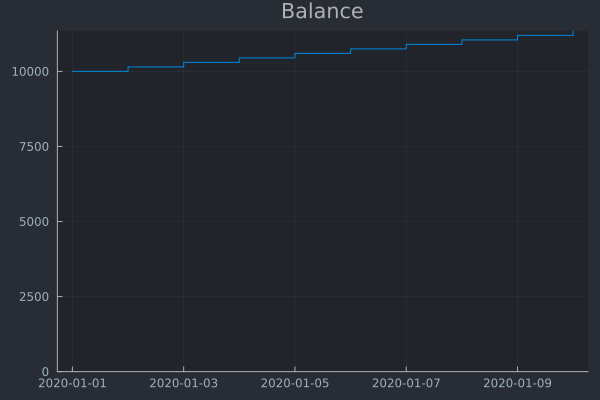

In [3]:
Fastback.plot_balance(balance_data)

Equity plot

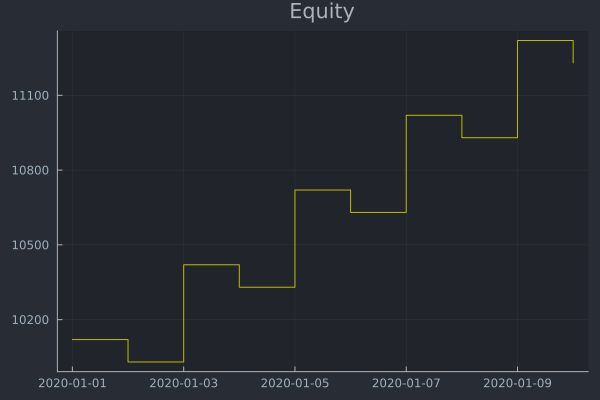

In [4]:
Fastback.plot_equity(equity_data)

Equity plot (sequence index)

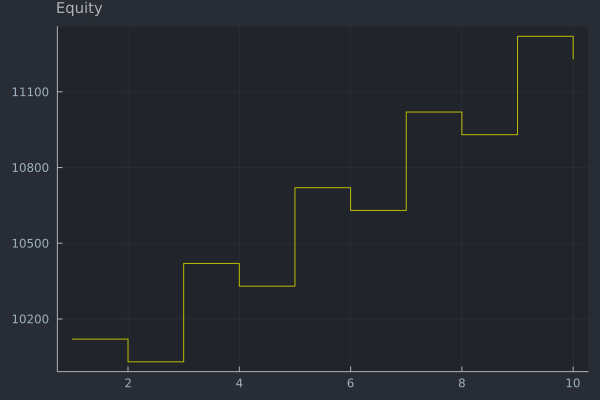

In [5]:
Fastback.plot_equity_seq(equity_data)

Open orders plot

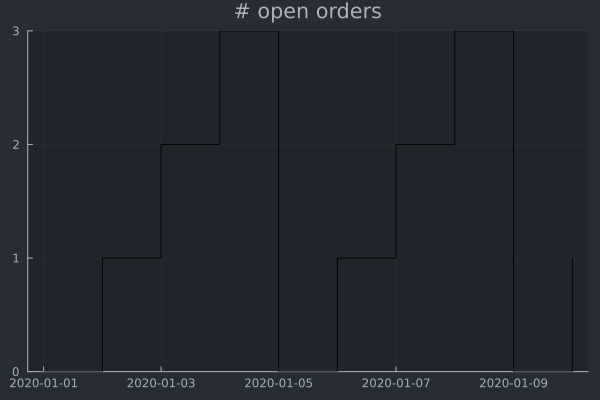

In [6]:
Fastback.plot_open_orders(open_orders_data)

Open orders plot (sequence index)

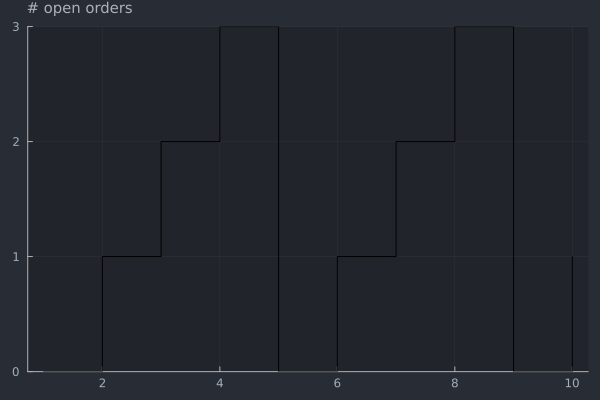

In [7]:
Fastback.plot_open_orders_seq(open_orders_data)

Drawdown plot

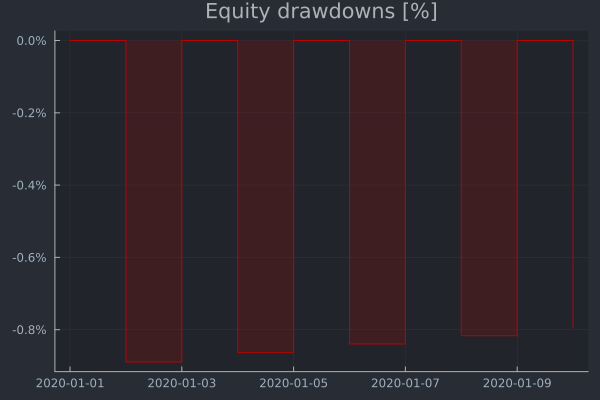

In [8]:
Fastback.plot_drawdown(drawdown_data)

Drawdown plot (sequence index)

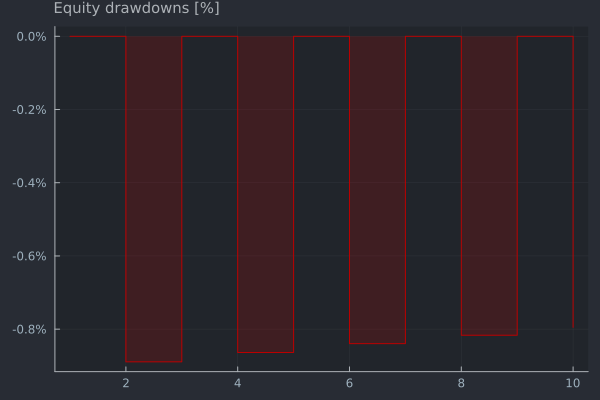

In [9]:
Fastback.plot_drawdown_seq(drawdown_data)

---------------------------------------------------------
Overlay helpers (plot_! variants)

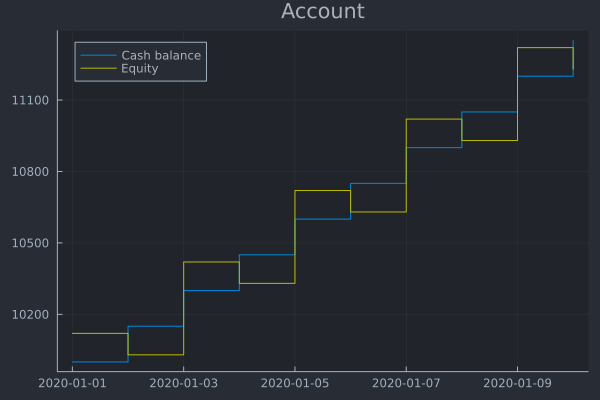

In [10]:
p = plot();
Fastback.plot_balance!(p, balance_data; title="Account");
Fastback.plot_equity!(p, equity_data);
p

---------------------------------------------------------
Synthetic trades for return-based plots

In [11]:
acc = Account(; mode=AccountMode.Margin, base_currency=:USD);
USD = Cash(:USD; digits=2);
deposit!(acc, USD, 10_000.0);
inst = register_instrument!(acc, Instrument(:XYZ, :XYZ, :USD; margin_mode=MarginMode.PercentNotional))

trade_specs = [
    (DateTime(2020, 1, 1, 9), DateTime(2020, 1, 1, 16), 100.0, 102.0),
    (DateTime(2020, 1, 2, 10), DateTime(2020, 1, 2, 15), 101.0, 99.0),
    (DateTime(2020, 1, 3, 11), DateTime(2020, 1, 3, 17), 100.5, 101.0),
    (DateTime(2020, 1, 6, 9), DateTime(2020, 1, 6, 14), 102.0, 98.5),
    (DateTime(2020, 1, 7, 13), DateTime(2020, 1, 7, 18), 99.5, 103.0),
];

for (open_dt, close_dt, open_px, close_px) in trade_specs
    open_order = Order(oid!(acc), inst, open_dt, open_px, 1.0)
    fill_order!(acc, open_order; dt=open_dt, fill_price=open_px, bid=open_px, ask=open_px, last=open_px)

    close_order = Order(oid!(acc), inst, close_dt, close_px, -1.0)
    fill_order!(acc, close_order; dt=close_dt, fill_price=close_px, bid=close_px, ask=close_px, last=close_px)
end

trades = filter(is_realizing, acc.trades);

---------------------------------------------------------
Return-based plots

Returns by day (violin)

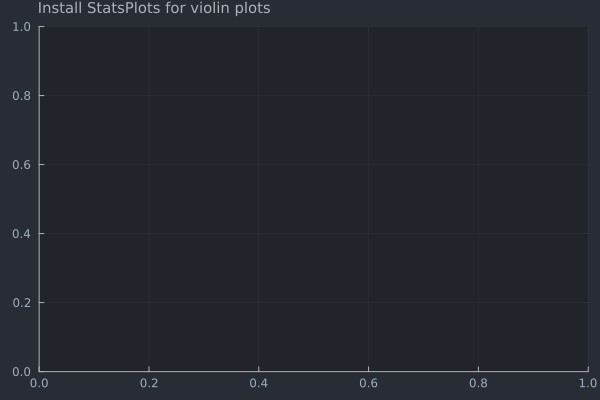

In [12]:
Fastback.violin_nominal_returns_by_day(trades)

Returns by hour (violin)

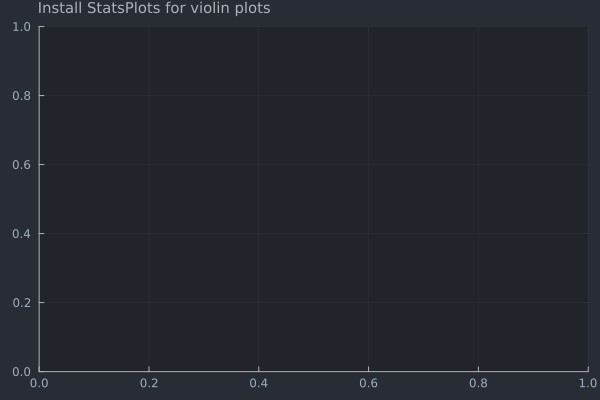

In [13]:
Fastback.violin_nominal_returns_by_hour(trades)

Cumulative returns by hour

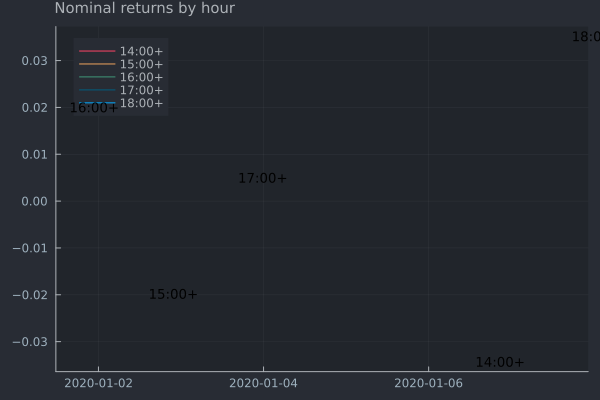

In [14]:
Fastback.plot_nominal_cum_returns_by_hour(trades)

Cumulative returns by hour (sequence index)

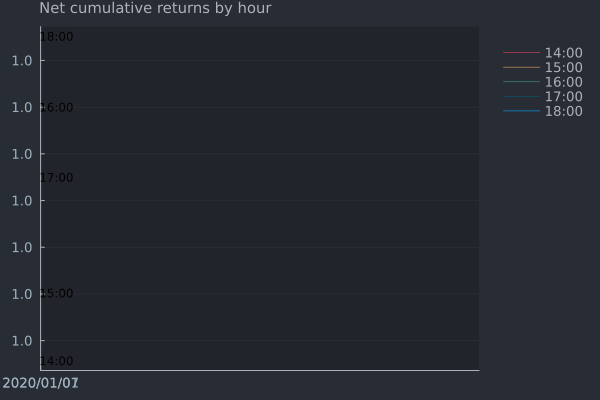

In [15]:
Fastback.plot_nominal_cum_returns_by_hour_seq_net(trades)

Cumulative returns by weekday

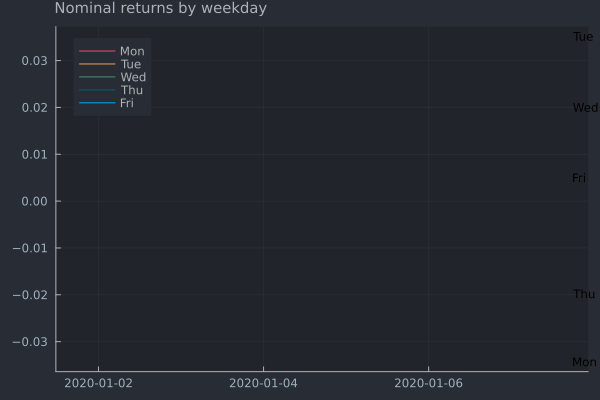

In [16]:
Fastback.plot_nominal_cum_returns_by_weekday(trades, t -> realized_return(t; zero_value=0.0))

Cumulative returns by weekday (sequence index)

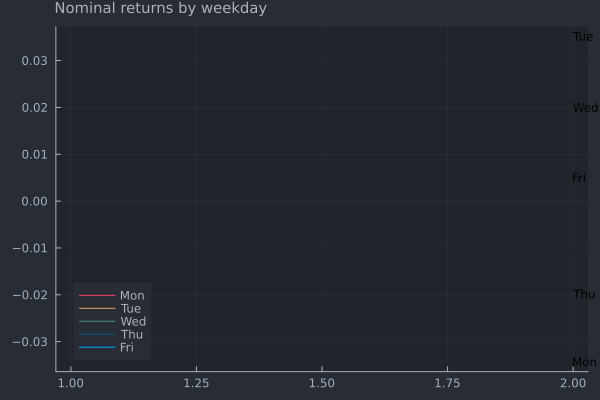

In [17]:
Fastback.plot_nominal_cum_returns_by_weekday_seq(trades, t -> realized_return(t; zero_value=0.0))